In [1]:
import pandas as pd
import numpy as np
import torch
import sys
sys.path.append('../')
from ML_utils import *

c:\working\xai_gnn_nids_hdr1\venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### BOt IOT

In [3]:
flows = pd.read_csv('../raw/d509c9db7490cf92_NFV3DATA-A11964_A11964/data/NF-BoT-IoT-v3.csv')

In [4]:
len(flows), flows.Attack.value_counts()

(16933808,
 Attack
 DoS               8034190
 DDoS              7150882
 Reconnaissance    1695132
 Benign              51989
 Theft                1615
 Name: count, dtype: int64)

In [5]:
flows['IPV4_SRC_ADDR'].nunique()

20

In [6]:
flows['IPV4_DST_ADDR'].nunique()

291

### NoT-IoT

In [7]:
flows = pd.read_csv('../raw/02934b58528a226b_NFV3DATA-A11964_A11964/data/NF-ToN-IoT-v3.csv')

In [8]:
flows.columns

Index(['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR',
       'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
       'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS',
       'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS',
       'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT',
       'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
       'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
       'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
       'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
       'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
       'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
       'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
       'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
       'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
       'DNS_TTL_ANSWER', 'FTP_COMMAN

In [9]:
flows.Attack.value_counts()

Attack
Benign        16792214
ddos           4141256
xss            2834435
password       1594777
scanning       1358977
injection       381777
dos             203456
Backdoor        203384
mitm              6013
ransomware        3971
Name: count, dtype: int64

In [10]:
# how many unique SRC IPs are there? 
flows['IPV4_SRC_ADDR'].nunique(), flows['IPV4_DST_ADDR'].nunique()

(15270, 8777)

In [11]:
flows['L4_SRC_PORT'].nunique(), flows['L4_DST_PORT'].nunique()

(65536, 65536)

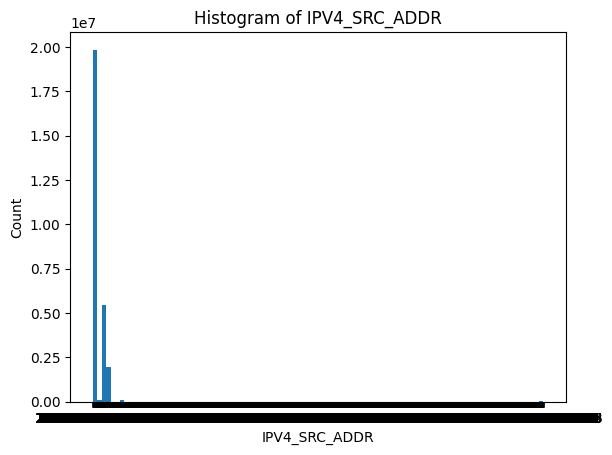

In [18]:
# histogram for inbound flows for each flow using matpltolib
import matplotlib.pyplot as plt
plt.hist(flows['IPV4_SRC_ADDR'], bins=100)
plt.xlabel('IPV4_SRC_ADDR')
plt.ylabel('Count')
plt.title('Histogram of IPV4_SRC_ADDR')
plt.show()


### CICIDS

In [3]:
flows = pd.read_csv('../raw/f78acbaa2afe1595_NFV3DATA-A11964_A11964/data/NF-CICIDS2018-v3.csv')


- Class	Count	Description
- Benign	17,514,626	Normal unmalicious flows
- BruteForce	575,194	A technique that aims to obtain usernames and password credentials by accessing a list of predefined - possibilities
- Bot	207,703	An attack that enables an attacker to remotely control several hijacked computers to perform malicious activities.
- DoS	302,966	An attempt to overload a computer system's resources with the aim of preventing access to or availability of its data.
- DDoS	1,324,350	An attempt similar to DoS but has multiple different distributed sources.
- Infiltration	188,152	An inside attack that sends a malicious file via an email to exploit an application and is followed by a - backdoor that scans the network for other vulnerabilities
- Web Attacks	2,538	A group that includes SQL injections, command injections and unrestricted file uploads

In [5]:
flows.columns

Index(['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR',
       'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
       'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS',
       'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS',
       'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT',
       'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
       'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
       'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
       'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
       'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
       'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
       'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
       'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
       'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
       'DNS_TTL_ANSWER', 'FTP_COMMAN

In [4]:
attacks = pd.unique(flows.Attack)
attacks

<StringArray>
[                  'Benign',           'FTP-BruteForce',
           'SSH-Bruteforce',    'DoS_attacks-GoldenEye',
    'DoS_attacks-Slowloris', 'DoS_attacks-SlowHTTPTest',
         'DoS_attacks-Hulk',   'DDoS_attacks-LOIC-HTTP',
     'DDOS_attack-LOIC-UDP',         'DDOS_attack-HOIC',
         'Brute_Force_-Web',         'Brute_Force_-XSS',
            'SQL_Injection',            'Infilteration',
                      'Bot']
Length: 15, dtype: str

In [8]:
attack_cat_mapping = {
	'BruteForce': ['SSH-Bruteforce', 'FTP-Bruteforce', 'Brute_Force_-Web', 'Brute_Force_-XSS', 'Brute_Force_-SQLi'],
	'Dos': ['DoS_attacks-Hulk', 'DoS_attacks-GoldenEye', 'DoS_attacks-Slowloris', 'DoS_attacks-SlowHTTPTest'],
	'DDoS': ['DDOS_attack-LOIC-UDP', 'DDoS_attacks-LOIC-HTTP', 'DDOS_attack-HOIC']
}

In [9]:
# convert attack labels to categories in mapping, if it occurs in the mapping lists
def map_attack_to_category(attack):
	for category, attack_list in attack_cat_mapping.items():
		if attack in attack_list:
			return category
	return attack  # return original label if not found in mapping

flows['Attack'] = flows['Attack'].apply(map_attack_to_category)
flows['Attack'].value_counts()

Attack
Benign            17514626
DDoS               1324350
FTP-BruteForce      386720
Dos                 302966
Bot                 207703
BruteForce          190572
Infilteration       188152
SQL_Injection          440
Name: count, dtype: int64

In [ ]:
# also remove sql injection
flows = flows[flows['Attack'] != 'SQL Injection']